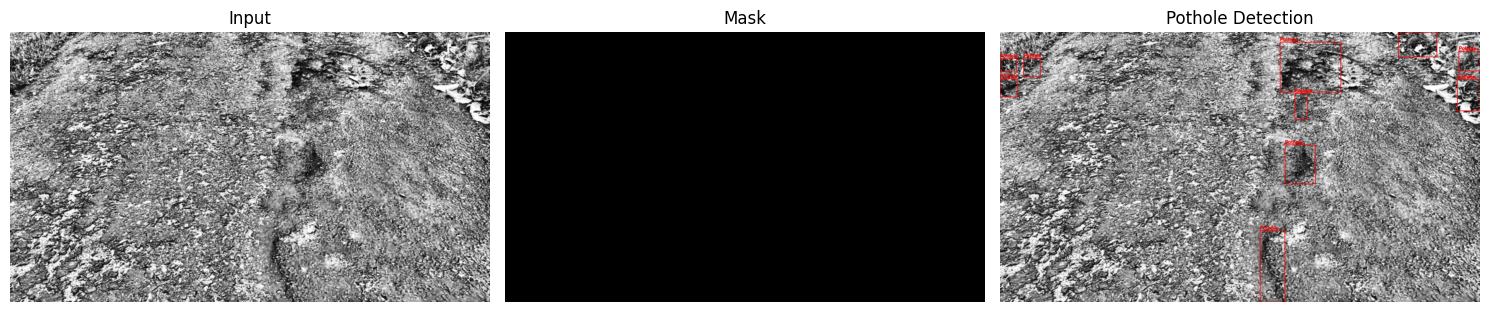

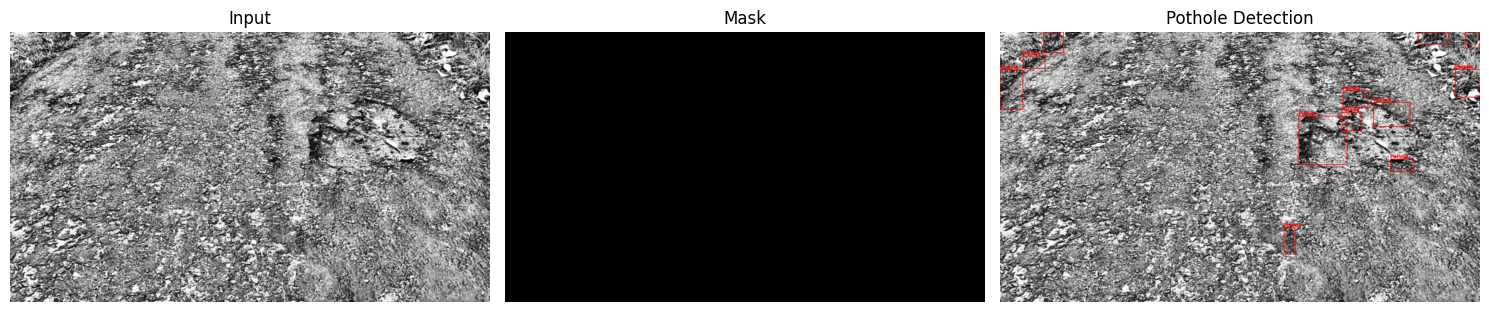

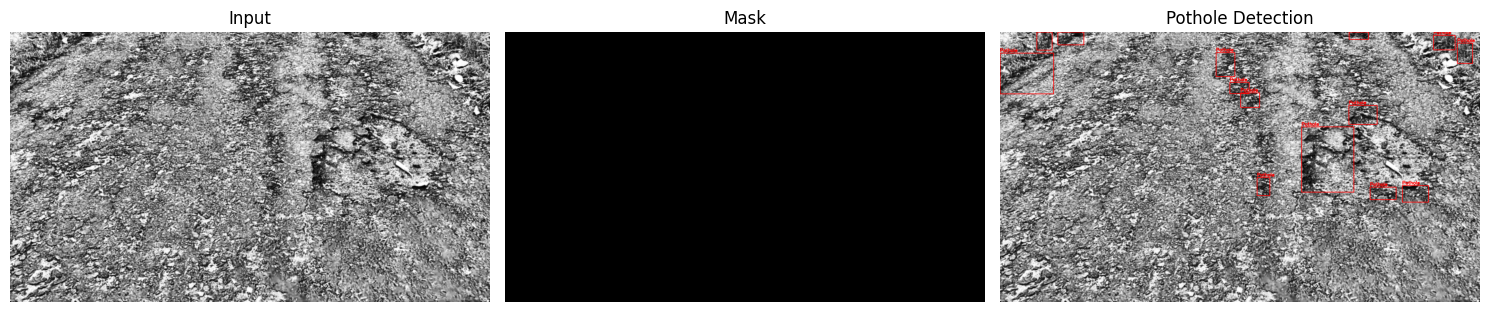

Pothole detection completed successfully!


In [ ]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

# Folder structure
input_folder = "../../frames/enhanced/4_FinalEnhanced/Pothole"
output_folder = "../../frames/segmented/Pothole"

os.makedirs(output_folder, exist_ok=True)

max_show = 3
count = 0


# Pothole detection function
def detect_pothole(gray, output, mask):

    blur = cv2.GaussianBlur(gray, (7,7), 0)

    _, th = cv2.threshold(
        blur,
        95,
        255,
        cv2.THRESH_BINARY_INV
    )

    th = cv2.bitwise_and(th, th, mask=mask)

    th = cv2.morphologyEx(
        th,
        cv2.MORPH_OPEN,
        np.ones((9,9), np.uint8)
    )

    th = cv2.morphologyEx(
        th,
        cv2.MORPH_CLOSE,
        np.ones((15,15), np.uint8)
    )

    contours, _ = cv2.findContours(
        th,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    count = 0

    for c in contours:

        area = cv2.contourArea(c)

        if area < 1500:
            continue

        x, y, w, h = cv2.boundingRect(c)

        if w / (h + 1e-5) > 3.5:
            continue

        cv2.rectangle(
            output,
            (x,y),
            (x+w,y+h),
            (0,0,255),
            2
        )

        cv2.putText(
            output,
            "Pothole",
            (x,y-5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0,0,255),
            2
        )

        count += 1

    return output


# Main processing loop
for file in os.listdir(input_folder):

    if file.endswith((".jpg", ".png", ".jpeg")):

        path = os.path.join(input_folder, file)
        img = cv2.imread(path)

        if img is None:
            continue

        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

        # Dummy full mask (since your original code expects mask)
        mask = np.ones_like(gray, dtype=np.uint8) * 255

        output = img.copy()

        # Step: pothole detection
        result = detect_pothole(gray, output, mask)

        # Save output
        cv2.imwrite(os.path.join(output_folder, file), result)

        # Visualization
        if count < max_show:

            plt.figure(figsize=(15, 5))

            plt.subplot(1, 3, 1)
            plt.imshow(gray, cmap="gray")
            plt.title("Input")
            plt.axis("off")

            plt.subplot(1, 3, 2)
            plt.imshow(mask, cmap="gray")
            plt.title("Mask")
            plt.axis("off")

            plt.subplot(1, 3, 3)
            plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
            plt.title("Pothole Detection")
            plt.axis("off")

            plt.tight_layout()
            plt.show()

            count += 1

print("Pothole detection completed successfully!")